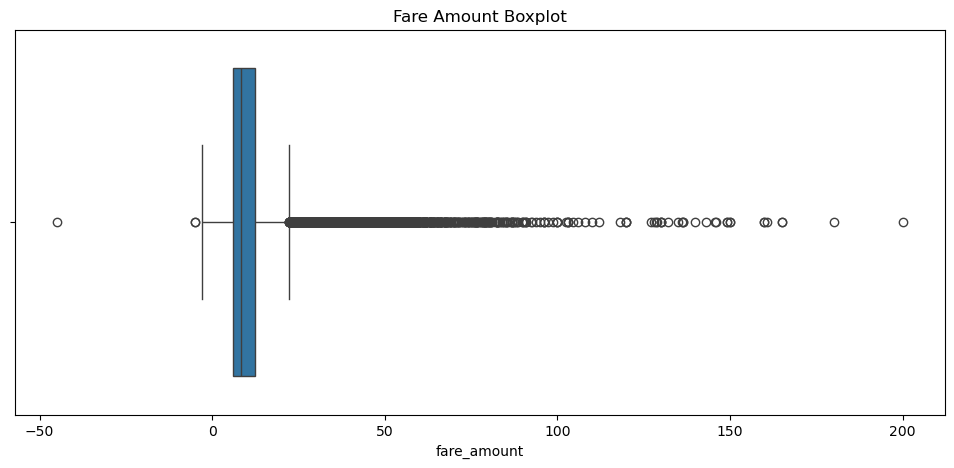

Standard Deviation Method: Detected 2727 anomalies
IQR Method: Detected 8718 anomalies


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (modify the path as needed)
data = pd.read_csv('train.csv', usecols=['fare_amount'], nrows=100000)  # Load only 100k rows

# Basic statistics
mean_fare = data['fare_amount'].mean()
std_fare = data['fare_amount'].std()
q1 = data['fare_amount'].quantile(0.25)
q3 = data['fare_amount'].quantile(0.75)
iqr = q3 - q1

# Define thresholds
std_threshold = 3
lower_std, upper_std = mean_fare - std_threshold * std_fare, mean_fare + std_threshold * std_fare
lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Detect anomalies
anomalies_std = data[(data['fare_amount'] < lower_std) | (data['fare_amount'] > upper_std)]
anomalies_iqr = data[(data['fare_amount'] < lower_iqr) | (data['fare_amount'] > upper_iqr)]

# Visualization
plt.figure(figsize=(12, 5))
sns.boxplot(x=data['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.show()

print(f"Standard Deviation Method: Detected {len(anomalies_std)} anomalies")
print(f"IQR Method: Detected {len(anomalies_iqr)} anomalies")


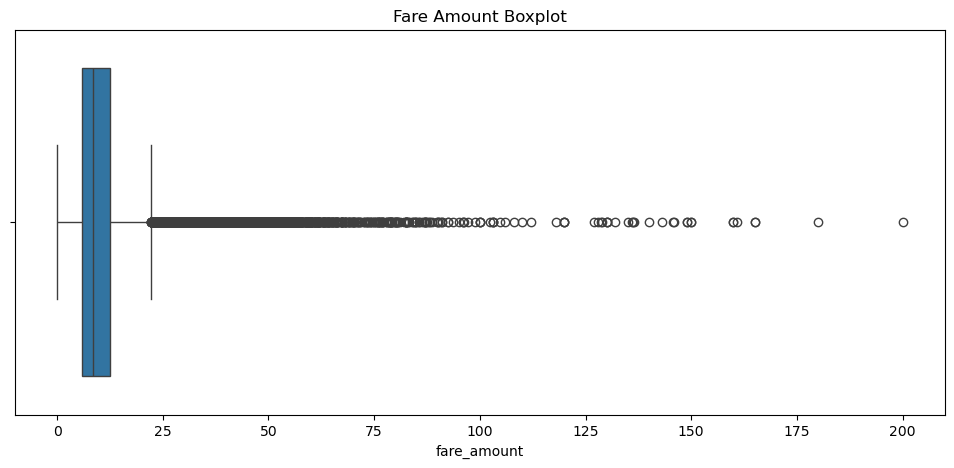

Standard Deviation Method: Detected 2726 anomalies
IQR Method: Detected 8715 anomalies
Isolation Forest: Detected 989 anomalies
One-Class SVM: Detected 1287 anomalies
False Positive Rate (Isolation Forest): 0.99%
False Positive Rate (One-Class SVM): 1.29%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

# Load dataset (modify the path as needed)
data = pd.read_csv('train.csv', usecols=['fare_amount'], nrows=100000)  # Load a subset to avoid memory issues

# Data Cleaning
data = data[(data['fare_amount'] > 0) & (data['fare_amount'] < 500)]  # Remove negative and extreme fares

# Statistical Approach (Day 1)
mean_fare = data['fare_amount'].mean()
std_fare = data['fare_amount'].std()
q1 = data['fare_amount'].quantile(0.25)
q3 = data['fare_amount'].quantile(0.75)
iqr = q3 - q1

# Threshold-Based Detection
std_threshold = 3
lower_std, upper_std = mean_fare - std_threshold * std_fare, mean_fare + std_threshold * std_fare
lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr

anomalies_std = data[(data['fare_amount'] < lower_std) | (data['fare_amount'] > upper_std)]
anomalies_iqr = data[(data['fare_amount'] < lower_iqr) | (data['fare_amount'] > upper_iqr)]

# Isolation Forest Model
iso_forest = IsolationForest(contamination=0.01, random_state=42)
data['iso_forest_label'] = iso_forest.fit_predict(data[['fare_amount']])
isolation_anomalies = data[data['iso_forest_label'] == -1]

# One-Class SVM Model
oc_svm = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
data['oc_svm_label'] = oc_svm.fit_predict(data[['fare_amount']])
one_class_anomalies = data[data['oc_svm_label'] == -1]

# Visualization
plt.figure(figsize=(12, 5))
sns.boxplot(x=data['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.show()

# Comparison
print(f"Standard Deviation Method: Detected {len(anomalies_std)} anomalies")
print(f"IQR Method: Detected {len(anomalies_iqr)} anomalies")
print(f"Isolation Forest: Detected {len(isolation_anomalies)} anomalies")
print(f"One-Class SVM: Detected {len(one_class_anomalies)} anomalies")

# Calculate False Positives (assuming majority of fares are normal)
def false_positive_rate(anomalies, total):
    return len(anomalies) / total * 100

total_samples = len(data)
print(f"False Positive Rate (Isolation Forest): {false_positive_rate(isolation_anomalies, total_samples):.2f}%")
print(f"False Positive Rate (One-Class SVM): {false_positive_rate(one_class_anomalies, total_samples):.2f}%")
